https://xe1t-wiki.lngs.infn.it/doku.php?id=xenon:xenonnt:ptan:nt_sr0_fd_config_home
SR1ERSource

In [ ]:
import os
import sys
sys.path.insert(0, "/cloud/wwu1/p_agweinheimer/AGW_LowRad/home/l_alth03/simulations/HermeticTPC/flamedisx")

In [2]:
from tqdm import tqdm
import numpy as np

import flamedisx as fd
import tensorflow as tf
import tensorflow_probability as tfp

import matplotlib.pyplot as plt
import matplotlib

2026-03-16 12:02:56.343050: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-16 12:02:56.360693: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-16 12:02:56.392204: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773662576.428489      90 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773662576.440608      90 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-16 12:02:56.492196: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

In [3]:
# For nT

#fd.xenon.data.BBF_PATH = "/cloud/wwu1/p_agweinheimer/AGW_LowRad/home/l_alth03/simulations/HermeticTPC/nT_Flame/BBF"
#fd.xenon.data.NTFD_PATH = "/cloud/wwu1/p_agweinheimer/AGW_LowRad/home/l_alth03/simulations/HermeticTPC/nT_Flame/flamedisx_maps"

#config_file = "/cloud/wwu1/p_agweinheimer/AGW_LowRad/home/l_alth03/simulations/HermeticTPC/nT_Flame/2024_Chiara_config_main.py"
#fd.SR1ERSource(config=config_file).print_config()

In [3]:
_drift_field = 240.0 # V/cm
_temperature = 177.0 # K
_pressure = 2.0 # bar

_density = fd.nest.calculate_density(_temperature, _pressure)
_drift_velocity = fd.nest.calculate_drift_velocity(_drift_field, _density, _temperature)

_drift_length = 297.0 # cm
_dt_min_config = 1 / _drift_velocity # was 0.3 before
_dt_max_config = _drift_length / _drift_velocity
print(f"Drift velocity: {_drift_velocity:.6f} cm/ns")
print(f"Minimum drift time: {_dt_min_config:.2f} ns")
print(f"Maximum drift time: {_dt_max_config:.2f} ns")

Drift velocity: 0.000156 cm/ns
Minimum drift time: 6401.80 ns
Maximum drift time: 1901333.78 ns


In [4]:
config = f"""
[NEST]

; Detector parameters - XLZD Nominal (WIMP Search Optimized)
temperature_config = {_temperature} ; K
pressure_config = {_pressure} ; bar
; XLZD DesignBook: 240 and 290 V/cm optimal
drift_field_config = {_drift_field} ; V/cm
; XLZD DesignBook: 6-8 kV/cm typically
gas_field_config = 6.0 ; kV/cm

; The required total mass of xenon assumes a
; 10cm charge-insensitive reverse field region below the
; cathode, a LXe Skin of 7cm between the TPC walls and
; the cryostat, and takes into account the LXe around
; and below the bottom PMTs.

; Target diameter [cm]: 298
; Target drift length [cm]: 297 (nominal), 396 (opportunity)
; Target mass [tonne]: 60 (nominal), 80 (opportunity)
; FV mass [tonne]: 48 (nominal), 64 (opportunity)
; Total mass [tonne]: 78 (nominal), 104 (opportunity)
z_topDrift_config = {_drift_length} ; cm
radius_config = 144.0 ; cm
dt_min_config = {_dt_min_config} ; ns
dt_max_config = {_dt_max_config} ; ns

g1_config = 0.125 ; Hohe Lichtausbeute ist kritisch für niedrige WIMP-Massen
elife_config = 10000000 ; ns

spe_res_config = 0.30
spe_thr_config = 0.35
spe_eff_config = 0.95

; A total of 1182 3-inch PMTs would be needed in the top
; and bottom PMT arrays, respectively -> 2364 total
num_pmts_config = 2364
double_pe_fraction_config = 0.20

; Selection parameters - WIMP Search Optimization
coin_level_config = 3 ; Dreifach-Koinzidenz zur Reduktion von Dark Counts bei großen PMT-Arrays
S1_min_config = 3.0   ; Mindestanzahl an Photonen (S1) für eine saubere Rekonstruktion
S1_max_config = 100.0 ; WIMPs erzeugen meist kleine S1-Signale
S2_min_config = 50.0 ; Entspricht etwa 1-2 extrahierten Elektronen (niedrige Schwelle)
S2_max_config = 10000 ; Obergrenze für typische WIMP-Region

gas_gap_config = 5.0 ; mm
g1_gas_config = 0.1
s2Fano_config = 3.6

S1_noise_config = 0.01 ; Realistisches Rauschen für die Hintergrundmodellierung
S2_noise_config = 0.01
"""

In [5]:
config_path = os.path.join(fd.__path__[0], 'nest', 'config', 'XLZD.ini')
with open(config_path, "w") as f:
    f.write(config)

In [6]:
mc_ER = fd.nest.nestERSource(detector="XLZD", energy_max=10).simulate(n_events=20000)
mc_NR = fd.nest.nestNRSource(detector="XLZD").simulate(n_events=20000)
mc_WIMP = fd.nest.nestWIMPSource(detector="XLZD", mw=10).simulate(n_events=20000)

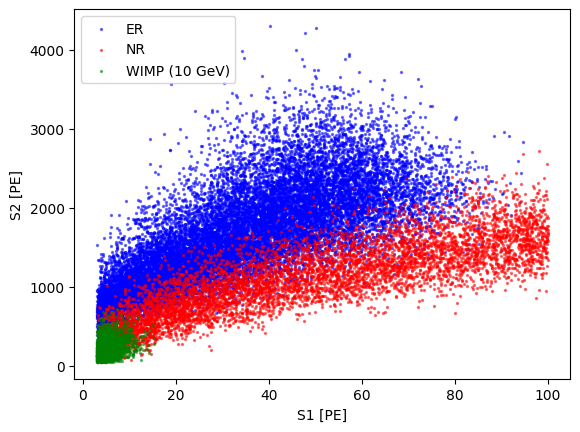

In [7]:
plt.scatter(mc_ER["s1"], mc_ER["s2"], s=2, alpha=0.5, label="ER", color="blue")
plt.scatter(mc_NR["s1"], mc_NR["s2"], s=2, alpha=0.5, label="NR", color="red")
plt.scatter(mc_WIMP["s1"], mc_WIMP["s2"], s=2, alpha=0.5, label="WIMP (10 GeV)", color="green")

plt.xlabel("S1 [PE]")
plt.ylabel("S2 [PE]")
#plt.xlim(0, 120)
#plt.ylim(0, 12000)
plt.legend()

plt.show()

In [8]:
exposure_scale = 0.02

def make_likelihood(wimp_mass, data=None, exposure_scale=1):

    class MyWIMP(fd.nest.nestWIMPSource):
        mw = wimp_mass
        
    class MyER(fd.nest.nestERSource):
        pass

    return fd.LogLikelihood(
        #defaults=dict(detector="XLZD"),
        sources=dict(er=MyER, wimp=MyWIMP),
        data=data,
        progress=False,
        # If you have a GPU, set an appropriate batch size here:
        batch_size = 100, # was 50
        free_rates=('er', 'wimp'))

In [9]:
#masses = np.array([10, 14, 20, 30, 40, 50, 70, 100, 140, 200])
masses = np.array([10, 200])

likelihoods = {mw: make_likelihood(mw, exposure_scale=exposure_scale)
               for mw in tqdm(masses, desc='Precreating likelihoods...')}

Precreating likelihoods...: 100%|██████████| 2/2 [00:03<00:00,  1.85s/it]


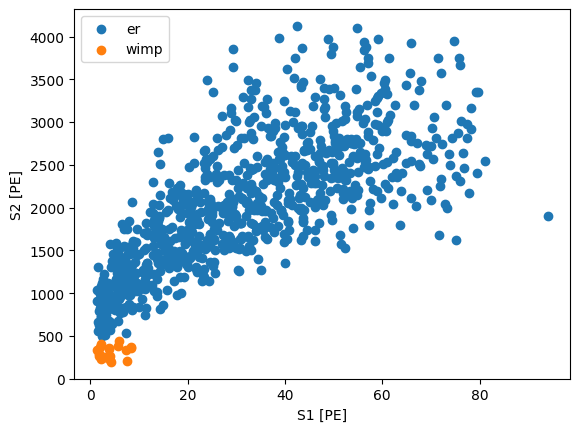

In [10]:
# True WIMP mass in GeV/c^2 and cross section in cm^2
true_mass = 10      # GeV/c^2
true_cross = 1e-45  # cm^2

ll = likelihoods[true_mass]
df = ll.simulate(wimp_rate_multiplier=true_cross/fd.WIMPEnergySpectrum.sigma_nucleon)

for label, d in df.groupby('source'):
    plt.scatter(d['s1'], d['s2'], label=label)

plt.legend(loc='upper left')
plt.xlabel("S1 [PE]")
plt.ylabel("S2 [PE]")
plt.show()

In [11]:
limits = np.zeros(len(masses))

for i, mw in enumerate(tqdm(masses)):
    ll = likelihoods[mw]
    ll.set_data(df)

    limits[i] = ll.limit('wimp_rate_multiplier')

# Convert from rate multiplier ('scale factor') to cross-section
limits *= fd.WIMPEnergySpectrum.sigma_nucleon

  0%|          | 0/2 [00:00<?, ?it/s]/opt/XENONnT/anaconda/envs/XENONnT_el9.2026.02.2/lib/python3.11/site-packages/scipy/stats/_distn_infrastructure.py:2046: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
/opt/XENONnT/anaconda/envs/XENONnT_el9.2026.02.2/lib/python3.11/site-packages/scipy/stats/_distn_infrastructure.py:2046: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
/opt/XENONnT/anaconda/envs/XENONnT_el9.2026.02.2/lib/python3.11/site-packages/scipy/stats/_distn_infrastructure.py:2046: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
/opt/XENONnT/anaconda/envs/XENONnT_el9.2026.02.2/lib/python3.11/site-packages/scipy/stats/_distn_infrastructure.py:2046: RuntimeWarning: divide by zero encountered in divide
  x = np.asarray((x - loc)/scale, dtype=dtyp)
  0%|          | 0/2 [00:14<?, ?it/s]


AssertionError: _annotate_special of <flamedisx.nest.lxe_blocks.detection.DetectElectrons object at 0x7fe5642b9490> set misordered bounds for dimension 'electrons_produced'. Count offending rows: 13. Examples (row,min,max): [(4, 82.0, 77.0), (8, 96.0, 78.0), (13, 79.0, 78.0), (24, 78.0, 77.0), (35, 100.0, 77.0), (39, 86.0, 78.0), (48, 82.0, 78.0), (49, 81.0, 78.0), (68, 86.0, 77.0), (83, 94.0, 78.0)]

In [ ]:
plt.plot(masses, limits, c='k', marker='.')

# Above 200 GeV, limit should scale (roughtly) with mass
ms = np.geomspace(200, 1e3, 100)
limit_200 = limits[-1]
plt.plot(ms, limit_200 * ms/200, c='k')

if true_cross > 0:
    plt.scatter([true_mass], [true_cross], marker='*', c='r')

plt.xscale('log')
plt.yscale('log')
plt.xlabel("WIMP mass [$\mathrm{GeV}/c^2$]")
plt.ylabel("WIMP cross-section [$\mathrm{cm}^2$]")

plt.tight_layout()
plt.show()